In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import cyipopt
import jax.numpy as jnp
import os
jax.config.update("jax_enable_x64", True)

In [ ]:
# Fixed Variables
mass = [0.10548177618443695, 0.07619744360415454]
length = [0.05, 0.05] 
gravity = 9.81

g = gravity
l1 = length[0]
l2 = length[1]
m1 = mass[0]  
m2 = mass[1]


peak_torque = 0.04  # peak torque in Nm
torque_limits = jnp.array([-peak_torque, peak_torque])  # torque limits in Nm


Q = jnp.diag(jnp.array([100.0, 100.0, 1.0, 1.0]))
Qfin =  Q
R = jnp.diag(jnp.array([1, 1])) * 0.01

# Initialize x_traj with random positions, but keep start and end fixed

    

In [3]:
# Dynamic's Matrices
def M(q):
	_, q2, _, _ = q
	m00 = l1**2 * m1 + l2**2 * m2 + l1**2 * m2 + 2 * l1 * m2 * l2 * jnp.cos(q2)
	m01 = l2**2 * m2 + l1 * m2 * l2 * jnp.cos(q2)
	m10 = l2**2 * m2 + l1 * m2 * l2 * jnp.cos(q2)
	m11 = l2**2 * m2 
	return jnp.array([[m00, m01], [m10, m11]])

def C(q):
	_, q2, q1_dot, q2_dot = q
	c00 = -2 * q2_dot * l1 * m2 * l2 * jnp.sin(q2)
	c01 = -q2_dot * l1 * m2 * l2 * jnp.sin(q2)
	c10 = q1_dot * l1 * m2 * l2 * jnp.sin(q2)
	c11 = 0.0
	return jnp.array([[c00, c01], [c10, c11]])

def G(q):
	q1, q2, _, _ = q
	g00 = -g * m1 * l1 * jnp.sin(q1) - g * m2 * (l1 * jnp.sin(q1) + l2 * jnp.sin(q1 + q2))
	g10 = -g * m2 * l2 * jnp.sin(q1 + q2)
	return jnp.array([[g00], [g10]])

In [4]:
def state_dist(x1, x2):
	"""xi = [q1, q2, q1_dot, q2_dot]
	Compute the distance between two states,wrapping angles properly 
	"""
	diff = x1 - x2
	diff = diff.at[0].set((diff[0] + jnp.pi) % (2 * jnp.pi) - jnp.pi)
	diff = diff.at[1].set((diff[1] + jnp.pi) % (2 * jnp.pi) - jnp.pi)
	return diff


In [5]:
def dynamics(x, u):
    # Ensure u is a column vector to match G(q) and C(q)@dq
    u = u.reshape(2, 1)
    q = x[:2]
    dq = x[2:].reshape(2, 1)
    
    ddq = jnp.linalg.solve(M(x), u - C(x) @ dq + G(x))
    

    return jnp.concatenate([dq, ddq]).flatten()

In [6]:
def rk4(x, u, dynamics, dt=0.01):
    k1 = dynamics(x, u).flatten()
    k2 = dynamics(x + 0.5 * dt * k1, u).flatten()
    k3 = dynamics(x + 0.5 * dt * k2, u).flatten()
    k4 = dynamics(x + dt * k3, u).flatten()
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [7]:
def l(xk, uk, x_goal):
    se = xk - x_goal
    return se.T @ Q @ se + uk.T @ R @ uk

def total_objective(z, steps, nx, nu, x_goal, dt=0.05):
    # z is the flattened decision vector [x0, x1, ..., xN, u0, u1, ..., uN-1]
    X = z[:steps * nx].reshape((steps, nx))
    U = z[steps * nx:].reshape((steps, nu))
    
    point_costs = jax.vmap(lambda x, u: l(x, u, x_goal)*0.5)(X, U)
    # 1. Final State Cost
    final_diff = X[-1] - x_goal
    point_costs = point_costs.at[-1].set(final_diff.T @ Qfin @ final_diff)
    # 2. Apply Weights 
    cost = jnp.sum(point_costs) 
    
    return cost


In [8]:
def l_deriv(xk, uk, x_goal):
    se = xk - x_goal
    grad_x = 2 * Q @ se
    grad_u = 2 * R @ uk
    return grad_x, grad_u

def total_objective_deriv(z, steps, nx, nu, x_goal, dt=0.05):
    # 1. Reshape z back into state and input trajectories
    X = z[:steps * nx].reshape((steps, nx))
    U = z[steps * nx:].reshape((steps , nu))
    
    # 2. Compute raw gradients at each time step using l_deriv
    point_grads_X, point_grads_U = jax.vmap(lambda x, u: l_deriv(x, u, x_goal))(X, U)
    
    # 3. Apply the weighting 
    weights = jnp.ones(steps)* 0.5

    # Broadcast weights to match the shape of gradients
    grad_X_weighted = point_grads_X * weights[:, None]
    grad_U_weighted = point_grads_U * weights[:, None]
    
    # 4. Add Terminal Cost Gradient
    # The terminal cost is applied only to the last state X[-1]
    terminal_grad_X = 2 * Qfin @ (X[-1] - x_goal)
    grad_X_weighted = grad_X_weighted.at[-1].set(terminal_grad_X)
    
    # 5. Flatten and concatenate to form the full gradient vector
    # Expected size: steps*nx + steps*nu
    grad = jnp.concatenate([grad_X_weighted.flatten(), grad_U_weighted.flatten()])
    
    return grad



In [9]:
def trapezoidal_collocation(x_k, x_kp1, u_k, u_kp1, dynamics, dt):
    """
    Enforces a linear consistency between two nodes.
    x_k, x_kp1: states at node k and k+1
    u_k, u_kp1: controls at node k and k+1
    returns: Scalar constraint value showing the collocation error
    """
    # 1. Compute dynamics at the nodes
    f_k = dynamics(x_k, u_k)
    f_kp1 = dynamics(x_kp1, u_kp1)
    
    # 2. Trapezoidal Rule constraint
    collocation_constraint = x_kp1 - x_k - (dt / 2.0) * (f_k + f_kp1)
    
    return collocation_constraint.flatten()

In [10]:
def constraints(z, steps, nx, nu, x0, x_goal, dt=0.05):
    X = z[:steps * nx].reshape((steps, nx))
    U = z[steps * nx:].reshape((steps, nu)) 
    
    # Initial state constraint
    c_init = X[0] - x0
    # We have 'steps - 1' intervals to constrain
    x_curr = X[:-1] # size: steps - 1
    x_next = X[1:]  # size: steps - 1
    
    u_curr = U[:-1] # size: steps - 1 
    u_next = U[1:]  # size: steps - 1 
    
    hs_vmap = jax.vmap(lambda xk, xkp1, uk, ukp1: 
                       trapezoidal_collocation(xk, xkp1, uk, ukp1, dynamics, dt))
    
    c_dyn = hs_vmap(x_curr, x_next, u_curr, u_next).flatten()
    
    # Final state constraint
    c_final = X[-1] - x_goal
    return jnp.concatenate([c_init, c_dyn, c_final])

In [11]:
class Problem:
	"""
 	Defines a minimization problem with the following form:
		min f(z) (z = [x0, x1, ..., xN, u0, u1, ..., uN-1])
	s.t. h(z) = 0
		lb <= z <= ub
	f(z) = objective function
	"""
	def __init__(self, steps, nx, nu, x0, xgoal, dt):
		self.steps = steps
		self.nx = nx # Number of states
		self.nu = nu # Number of inputs
		print(f"Problem initialized with {steps} steps, {nx} states, {nu} inputs.")
		# JIT-compiled functions with fixed problem dimensions and xgoal/x0
		self._obj_jit = jax.jit(lambda z: total_objective(z, self.steps, self.nx, self.nu, xgoal)) # f(z)
		# self._grad_jit = jax.jit(jax.grad(lambda z: total_objective(z, self.steps, self.nx, self.nu, xgoal))) #	nablaf(z)
		self._grad_jit = lambda z: total_objective_deriv(z, self.steps, self.nx, self.nu, xgoal)
		
  		# pass x0 and xgoal into constraints/jacobian to match signature
		self._cons_jit = jax.jit(lambda z: constraints(z, self.steps, self.nx, self.nu, x0, xgoal, dt)) # h(z)
		self._jac_jit = jax.jit(jax.jacobian(lambda z: constraints(z, self.steps, self.nx, self.nu, x0, xgoal, dt))) # nablag(z)

	def objective(self, z):
		return float(self._obj_jit(z))

	def gradient(self, z):
		return np.array(self._grad_jit(z)).ravel().astype(np.float64)

	def constraints(self, z):
		return np.array(self._cons_jit(z))

	def jacobian(self, z):
		jac = self._jac_jit(z)
		# return flattened Jacobian (rows*cols) - matches earlier usage
		return jac.ravel()

In [12]:
# Simulation parameters
T = 2 # Total simulation time in seconds
dt = 0.05
steps = int(T / dt) + 1
time_span = jnp.linspace(0, T, steps)

# Initial state
x0 = jnp.array([0.0, 0.0, 0.0, 0.0])
xgoal = jnp.array([jnp.pi, 0.0, 0.0, 0.0])
# Storage for history
x_history = [x0]
u_history = []
force_history = []

# Initialize x_traj with random positions, but keep start and end fixed
key = jax.random.PRNGKey(0)
x_traj = jax.random.uniform(key, shape=(steps, 4), minval=-jnp.pi, maxval=jnp.pi)
u_traj = jax.random.uniform(key, shape=(steps, 2), minval=torque_limits[0], maxval=torque_limits[1])

x_traj = x_traj.at[0].set(x0)
x_traj = x_traj.at[-1].set(xgoal)

grad_func = jax.jit(jax.grad(total_objective), static_argnums=(1, 2, 3))


nx = 4
nu = 2
num_vars = steps * nx + steps * nu
num_constraints = (steps - 1) * nx + nx + nx 
 

x_init_guess = jnp.zeros((steps, 4))
x_init_guess = x_init_guess.at[:, 0].set(jnp.linspace(0, jnp.pi, steps))
z0 = jnp.concatenate([x_init_guess.flatten(), u_traj.flatten()])

# Initial guess
z0 = jnp.concatenate([x_traj.flatten(), u_traj.flatten()])

# Bounds for variables
# State bounds unbounded
x_lb = jnp.full((steps, nx), -jnp.inf)
x_ub = jnp.full((steps, nx), jnp.inf)
# Input bounds
u_lb = jnp.full((steps, nu), torque_limits[0])
u_ub = jnp.full((steps, nu), torque_limits[1])

lb = jnp.concatenate([x_lb.flatten(), u_lb.flatten()])
ub = jnp.concatenate([x_ub.flatten(), u_ub.flatten()])
# set the second motor torque limits tighter

# Constraint bounds: equality constraints (dynamics + initial state) => zeros
cl = jnp.zeros(num_constraints)
cu = jnp.zeros(num_constraints)


problem = cyipopt.Problem(
	n=num_vars,
	m=num_constraints,
	problem_obj=Problem(steps, nx, nu, x0, xgoal, dt),
	lb=lb,
	ub=ub,
	cl=cl,
	cu=cu
)


# Set options
problem.add_option('max_iter', 100)
problem.add_option('tol', 1e-3)
problem.add_option('print_level', 0) # 5 is default, 0 is silent

# Solve
z_opt, info = problem.solve(z0)

# Unpack results
x_traj = z_opt[:steps * nx].reshape((steps, nx))
u_traj = z_opt[steps * nx:].reshape((steps, nu))
force_history = u_traj


Problem initialized with 41 steps, 4 states, 2 inputs.

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



last second 2.0 [3.14159265e+00 3.86443236e-27 0.00000000e+00 0.00000000e+00]


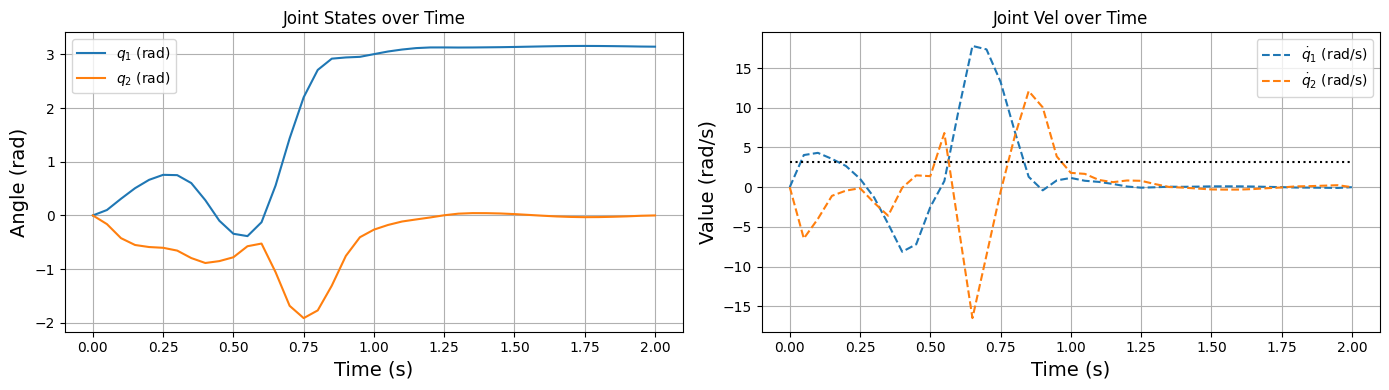

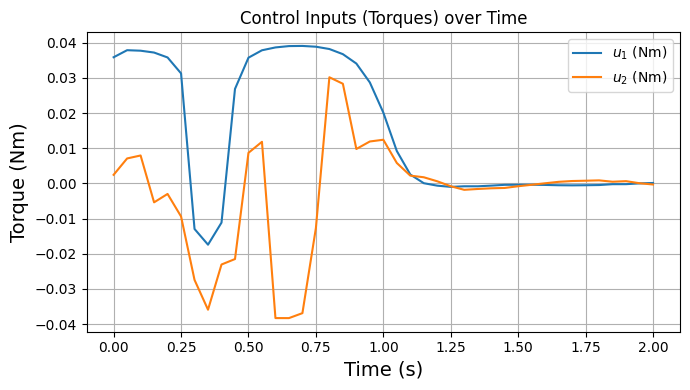

In [13]:
# Plots
x_history = jnp.array(x_history)
ref = jnp.ones(steps) * jnp.pi
font = 14
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
print("last second", time_span[-1], x_traj[-1])

# Plot Joint Angles
ax1.plot(time_span, x_traj[:, 0], label=r'$q_1$ (rad)')
ax1.plot(time_span, x_traj[:, 1], label=r'$q_2$ (rad)')
ax1.set_title('Joint States over Time')
ax1.set_ylabel('Angle (rad)', fontsize=font)
ax1.set_xlabel('Time (s)', fontsize=font)
ax1.legend()
ax1.grid(True)

# Plot Joint Velocities
ax2.plot(time_span, x_traj[:, 2], label=r'$\dot{q}_1$ (rad/s)', linestyle='--')
ax2.plot(time_span, x_traj[:, 3], label=r'$\dot{q}_2$ (rad/s)', linestyle='--')
ax2.plot(time_span, ref, 'k:')
ax2.set_title('Joint Vel over Time')
ax2.set_ylabel('Value (rad/s)', fontsize=font)
ax2.set_xlabel('Time (s)', fontsize=font)
ax2.legend()
ax2.grid(True)

plt.tight_layout()

# plot Forces
plt.figure(figsize=(7, 4))
plt.plot(time_span[:], force_history[:, 0], label=r'$u_1$ (Nm)')
plt.plot(time_span[:], force_history[:, 1], label=r'$u_2$ (Nm)')
plt.title('Control Inputs (Torques) over Time')
plt.xlabel('Time (s)',fontsize=font)
plt.ylabel('Torque (Nm)',fontsize=font)
plt.legend()
plt.grid(True)
plt.tight_layout()
# Construct filename suffix from Q and R matrices
q_diag = jnp.diag(Q)
r_diag = jnp.diag(R)
# filename_suffix = f"R_{int(r_diag[0])}_{int(r_diag[1])}_Q_{int(q_diag[0])}_{int(q_diag[1])}_{int(q_diag[2])}_{int(q_diag[3])}"

# # Save figures
# fig_joint_states = plt.figure(1)
# fig_torques = plt.figure(2)

# fig_joint_states.savefig(f"Joint_states_{filename_suffix}.png")
# fig_torques.savefig(f"Torques_{filename_suffix}.png")

plt.show()


In [ ]:
output_dir = os.path.join(os.path.dirname(__file__), "results")
os.makedirs(output_dir, exist_ok=True)
np.savetxt(os.path.join(output_dir, "trajectory.csv"), x_traj, delimiter=",", header="q1,q2,q1_dot,q2_dot", comments="")
np.savetxt(os.path.join(output_dir, "inputs.csv"), u_traj, delimiter=",", header="u1,u2", comments="")

/home/nickv/Documents/School/group_project_TN2/double_pendulum


FileNotFoundError: [Errno 2] No such file or directory: '/resuls/trajectory.csv'

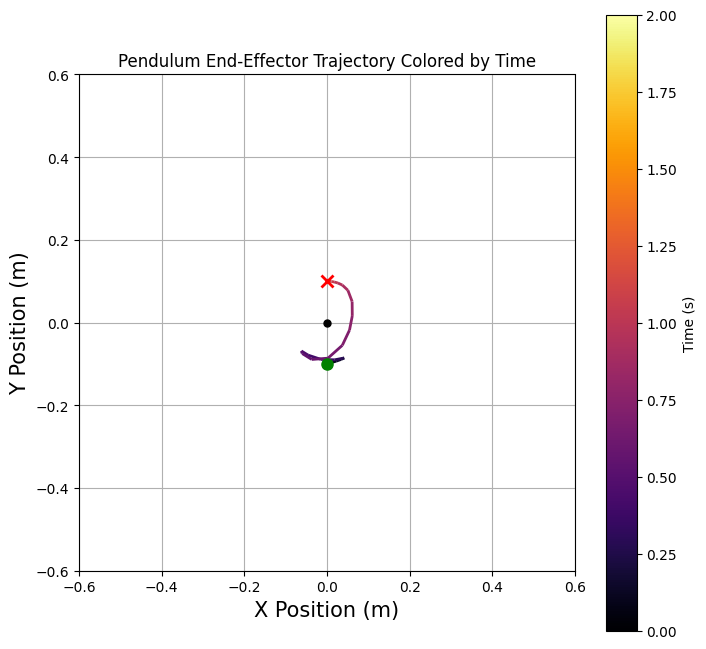

In [ ]:
from matplotlib.collections import LineCollection


# --- 1. Data Preparation (Same as your animation setup) ---
q1 = x_traj[:, 0]
q2 = x_traj[:, 1]

# Position of the first pendulum bob (inner)
x1 = l1 * jnp.sin(q1)
y1 = -l1 * jnp.cos(q1)

# Position of the second pendulum bob (outer - the one we usually track)
x2 = x1 + l2 * jnp.sin(q1 + q2)
y2 = y1 - l2 * jnp.cos(q1 + q2)

# Create a time array for the color mapping
t_points = np.arange(len(x2)) * dt

# --- 2. Create the Gradient Plot ---
fig, ax = plt.subplots(figsize=(8, 8))

# Create a set of line segments so each segment can have a different color
# Points are (x, y) pairs. We connect point i to point i+1
points = np.array([x2, y2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection
# 'cmap' controls the color scheme (viridis, plasma, inferno, etc.)
# 'norm' maps the time values to the 0-1 range of the colormap
norm = plt.Normalize(t_points.min(), t_points.max())
lc = LineCollection(segments, cmap='inferno', norm=norm)

# Set the variable used for coloring (time)
lc.set_array(t_points)
lc.set_linewidth(2)

# Add the collection to the plot
ax.add_collection(lc)

# --- 3. Add Visual Reference Points ---
# Plot the starting point (Green Circle)
ax.plot(x2[0], y2[0], 'go', markersize=8, label='Start', zorder=10)

# Plot the end point (Red X)
ax.plot(x2[-1], y2[-1], 'rx', markersize=8, markeredgewidth=2, label='End', zorder=10)

# Plot the pivot point (0,0)
ax.plot(0, 0, 'ko', markersize=5, label='Pivot')

# --- 4. Formatting ---
# Add a colorbar to show the time progression
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label('Time (s)')

ax.set_xlim(-(l1 + l2 + 0.5), (l1 + l2 + 0.5))
ax.set_ylim(-(l1 + l2 + 0.5), (l1 + l2 + 0.5))
ax.set_aspect('equal')
plt.grid()
plt.title('Pendulum End-Effector Trajectory Colored by Time')
plt.xlabel('X Position (m)',fontsize=15)
plt.ylabel('Y Position (m)',fontsize=15)
# plt.tight_layout()
# Construct filename from Q and R matrices
q_diag = jnp.diag(Q)
r_diag = jnp.diag(R)
filename = f"Traject_R_{int(r_diag[0])}_{int(r_diag[1])}_Q_{int(q_diag[0])}_{int(q_diag[1])}_{int(q_diag[2])}_{int(q_diag[3])}.png"

# Save the plot
# plt.savefig(filename)
plt.show()

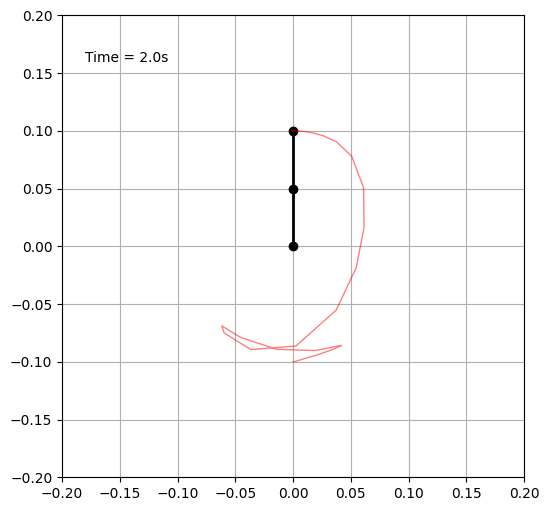

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Convert joint angles to Cartesian coordinates
# x_history columns: 0: q1, 1: q2, 2: q1_dot, 3: q2_dot
q1 = x_traj[:, 0]
q2 = x_traj[:, 1]

# Position of the first pendulum bob
x1 = l1 * jnp.sin(q1)
y1 = -l1 * jnp.cos(q1)

# Position of the second pendulum bob
x2 = x1 + l2 * jnp.sin(q1 + q2)
y2 = y1 - l2 * jnp.cos(q1 + q2)

# 2. Set up the animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-(l1 + l2 + 0.1), (l1 + l2 + 0.1))
ax.set_ylim(-(l1 + l2 + 0.1), (l1 + l2 + 0.1))
ax.set_aspect('equal')
ax.grid()

# Plot elements: line for rods, points for masses, and a trace line
line, = ax.plot([], [], 'o-', lw=2, color='black')
trace, = ax.plot([], [], '-', lw=1, color='red', alpha=0.5)
time_template = 'Time = %.1fs'
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)

# History for the trace
trace_x, trace_y = [], []

def init():
	line.set_data([], [])
	trace.set_data([], [])
	time_text.set_text('')
	return line, trace, time_text

def animate(i):
	# Current positions
	thisx = [0, x1[i], x2[i]]
	thisy = [0, y1[i], y2[i]]

	# Update pendulum rods and bobs
	line.set_data(thisx, thisy)

	# Update trace
	trace_x.append(x2[i])
	trace_y.append(y2[i])
	# Keep trace length manageable if needed, or plot full history
	trace.set_data(trace_x, trace_y)

	time_text.set_text(time_template % (i * dt))
	return line, trace, time_text
# Create animation
ani = FuncAnimation(fig, animate, frames=len(time_span),
					init_func=init, interval=dt*1000, blit=True)
plt.rcParams['animation.embed_limit'] = 21.0 # Set embed limit to 21MB

# To display in Jupyter Notebook
HTML(ani.to_jshtml())